### Network Map-type thing of all the poems?

1. Filter out all the common words from each poem
2. Create a wide df where each word is its own column
3. Pivot it long so that the columns are Poem & Word Number & Word

In [1]:
import pandas as pd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

In [2]:
df = pd.read_csv('df_long.csv')

In [9]:
# Build edge list: for each poem, zip consecutive words into (word_i, word_i+1) pairs
edges = []
for (title, poet), group in df.groupby(["Title", "Poet"]):
    words = group.sort_values("position")["word"].dropna().tolist()  # add .dropna()
    for w1, w2 in zip(words, words[1:]):
        edges.append((w1.lower(), w2.lower()))

# Create graph — using a set of edges collapses duplicates automatically
G = nx.Graph()
G.add_edges_from(edges)  # nodes are created implicitly; duplicate edges are ignored in Graph

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


Nodes: 90268, Edges: 1041675


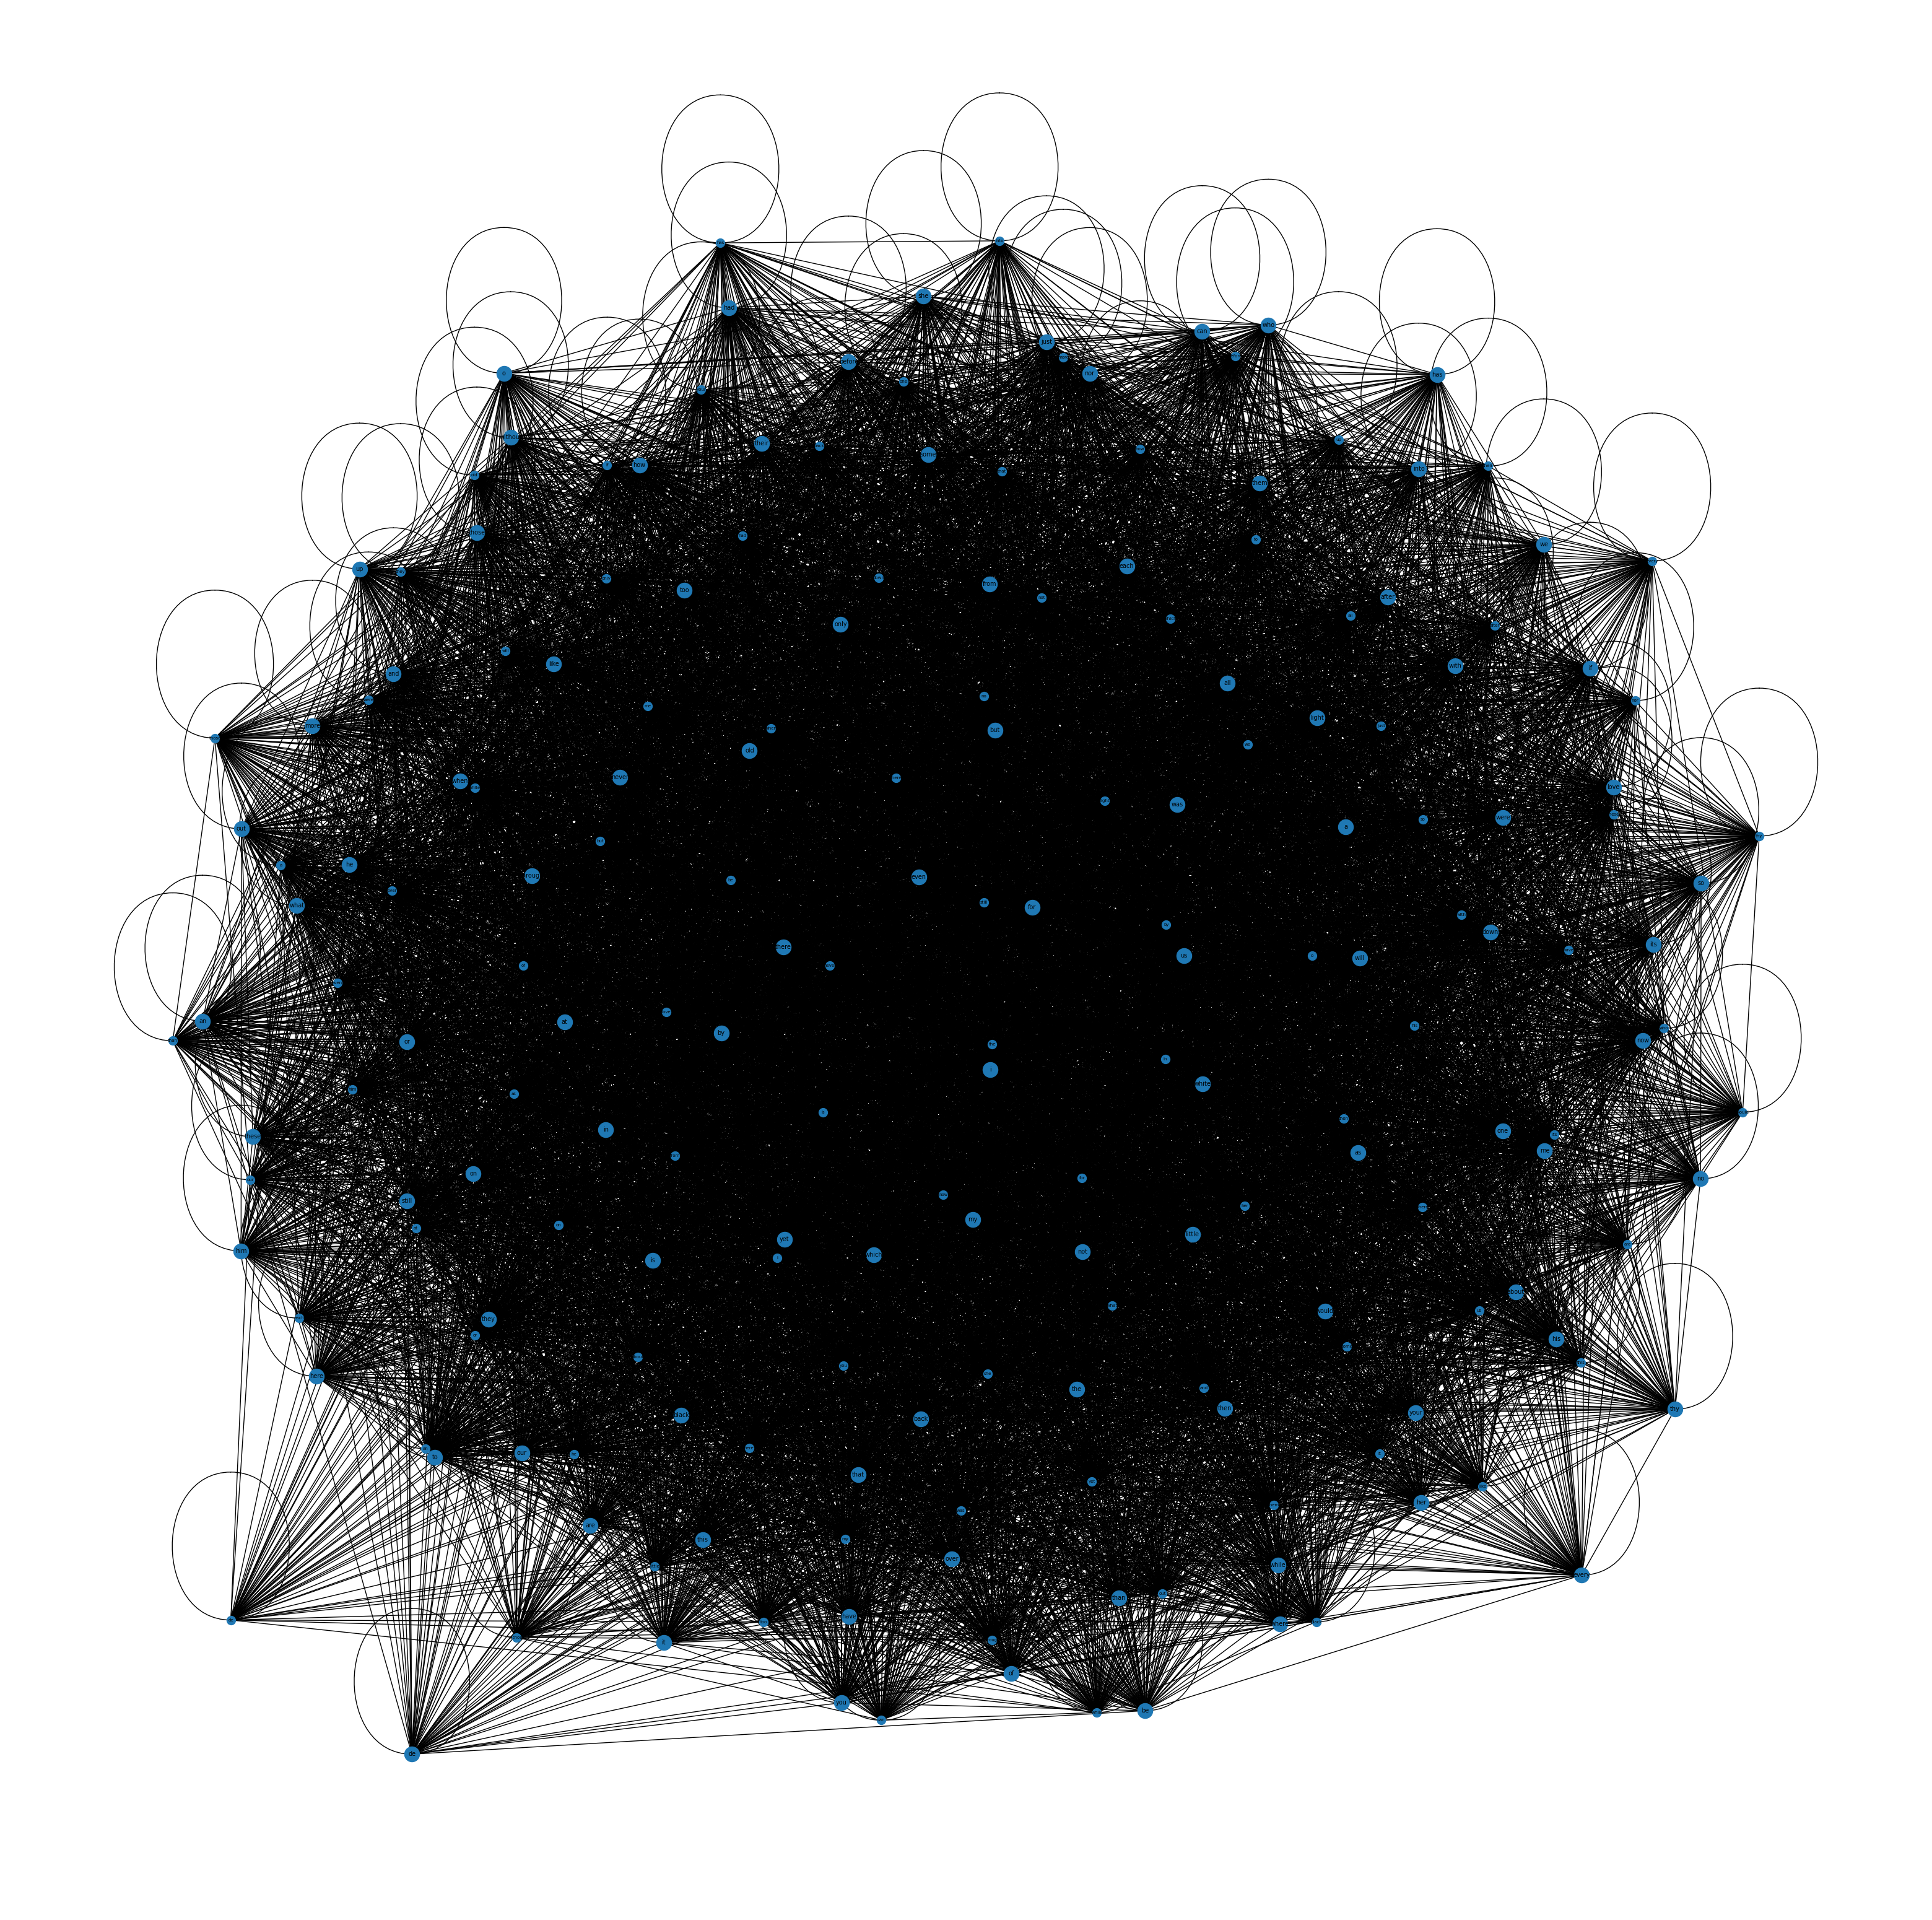

In [10]:
# Filter to most connected nodes
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:100]
subgraph = G.subgraph([n for n, _ in top_nodes])

plt.figure(figsize=(40, 40))  # much larger canvas
pos = nx.spring_layout(subgraph, seed=42, k=2)  # k controls spacing between nodes (default ~1)
nx.draw_networkx(subgraph, pos=pos, node_size=100, font_size=5, with_labels=True)

nx.draw_networkx(subgraph, pos=nx.spring_layout(subgraph, seed=42),
                 node_size=300, font_size=7, with_labels=True)
plt.axis("off")
plt.show()
